In [ ]:
!pip install pyspark

In [ ]:
!pip install pyarrow

In [ ]:
from pyspark.sql import SparkSession

spark=SparkSession.builder.appName("DF_1").getOrCreate()


folder_path = "/content/final_table.parquet"

df = spark.read.parquet(folder_path)

df.show(5)


+---------+-----------+------------------+------------+-----------------+------------------+---------+-------------+-----+
|  user_id|total_spent|avg_purchase_price|recency_days|product_diversity|category_diversity|purchases|session_count|churn|
+---------+-----------+------------------+------------+-----------------+------------------+---------+-------------+-----+
|548496387|    2633.74|           1316.87|           5|                2|                 1|        2|            3|    0|
|555470672|    1413.16|           1413.16|          14|                1|                 1|        1|            1|    1|
|536658095|     980.68|            490.34|          14|                2|                 5|        2|            1|    1|
|520295401|    2234.27| 744.7566666666667|           6|                2|                 1|        3|            3|    0|
|548975663|     257.15|            257.15|           0|                1|                 2|        1|            7|    0|
+---------+-----

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "purchases",
        "total_spent",
        "avg_purchase_price",
        "product_diversity",
        "category_diversity",
        "session_count",
    ],
    outputCol="features"
)

ml_data = assembler.transform(df)

In [ ]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)

scaler_model = scaler.fit(ml_data)
ml_data = scaler_model.transform(ml_data)

In [ ]:
train_df, test_df = ml_data.randomSplit([0.8, 0.2], seed=42)

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="scaled_features",  # USE SCALED
    labelCol="churn",
    numTrees=100,
    maxDepth=10
)

model = rf.fit(train_df)

In [ ]:
predictions = model.transform(test_df)

predictions.select(
    "user_id",
    "churn",
    "prediction",
    "probability"
).show(5)

+---------+-----+----------+--------------------+
|  user_id|churn|prediction|         probability|
+---------+-----+----------+--------------------+
|340041246|    0|       0.0|[0.83040990873571...|
|415153398|    0|       0.0|[0.62844402062778...|
|425101109|    0|       0.0|[0.63616840786121...|
|434170823|    0|       0.0|[0.89852392858281...|
|440756116|    1|       0.0|[0.61848439522092...|
+---------+-----+----------+--------------------+
only showing top 5 rows


In [ ]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    labelCol="churn",
    featuresCol="scaled_features",
    maxIter=100
)

gbt_model = gbt.fit(train_df)

In [ ]:
scaler_model.write().overwrite().save("churn_gbt_scaler")
gbt_model.write().overwrite().save("churn_gbt_model")

In [ ]:
import shutil
shutil.make_archive("churn_gbt_model", "zip", "churn_gbt_model")

'/content/churn_gbt_model.zip'

In [ ]:

predictions_gbt_model = gbt_model.transform(test_df)

predictions_gbt_model.select(
    "user_id",
    "churn",
    "prediction",
    "probability"
).show(5)

+---------+-----+----------+--------------------+
|  user_id|churn|prediction|         probability|
+---------+-----+----------+--------------------+
|340041246|    0|       0.0|[0.84388324513598...|
|415153398|    0|       0.0|[0.63559656590884...|
|425101109|    0|       0.0|[0.63537068761290...|
|434170823|    0|       0.0|[0.89920351795741...|
|440756116|    1|       0.0|[0.64486663703712...|
+---------+-----+----------+--------------------+
only showing top 5 rows


In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="churn",
    metricName="areaUnderROC"
)

auc = evaluator.evaluate(predictions)
print("AUC:", auc)

AUC: 0.7368928820697503


In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="churn",
    metricName="areaUnderROC"
)

auc = evaluator.evaluate(predictions_gbt_model)
print("AUC:", auc)

AUC: 0.7423117146043623


In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

f1_eval = MulticlassClassificationEvaluator(
    labelCol="churn",
    metricName="f1"
)

print("F1 Score:", f1_eval.evaluate(predictions))

F1 Score: 0.7154264176082755


In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

f1_eval = MulticlassClassificationEvaluator(
    labelCol="churn",
    metricName="f1"
)

print("F1 Score:", f1_eval.evaluate(predictions_gbt_model))

F1 Score: 0.726687033231441


# Model 2 customer segmentation

In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.sql.functions import col, when

In [ ]:
feature_cols = [
    "purchases",
    "total_spent",
    "avg_purchase_price",
    "product_diversity",
    "category_diversity",
    "session_count"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features2"
)

ml_data = assembler.transform(df)

In [ ]:
from pyspark.ml.feature import StandardScaler

scaler2 = StandardScaler(
    inputCol="features2",
    outputCol="scaled_features2",
    withStd=True,
    withMean=True
)

scaler_model2 = scaler2.fit(ml_data)
ml_data2 = scaler_model2.transform(ml_data)

In [ ]:
kmeans = KMeans(
    featuresCol="scaled_features2",
    k=3,
    seed=42
)
k_model = kmeans.fit(ml_data2)
clusters = k_model.transform(ml_data2)

In [ ]:
scaler_model2.write().overwrite().save("segment_kmeans_scaler")
k_model.write().overwrite().save("segment_kmeans_model")

In [ ]:
import shutil
shutil.make_archive("segment_kmeans_model", "zip", "segment_kmeans_model")

'/content/segment_kmeans_model.zip'

In [ ]:
from pyspark.sql.functions import when, col

clusters_labeled = clusters.withColumn(
    "customer_segment",
    when(col("prediction") == 2, "High-Value")
    .when(col("prediction") == 0, "Regular")
    .when(col("prediction") == 1, "At-Risk")
)

In [ ]:
clusters_labeled.groupBy("customer_segment").count().show()

+----------------+------+
|customer_segment| count|
+----------------+------+
|      High-Value| 12138|
|         Regular| 23185|
|         At-Risk|149012|
+----------------+------+



In [ ]:
clusters_labeled.groupBy("customer_segment").avg(
    "total_spent",
    "purchases",
    "avg_purchase_price",
    "product_diversity",
    "category_diversity",
    "session_count"
).show()

+----------------+------------------+------------------+-----------------------+----------------------+-----------------------+------------------+
|customer_segment|  avg(total_spent)|    avg(purchases)|avg(avg_purchase_price)|avg(product_diversity)|avg(category_diversity)|avg(session_count)|
+----------------+------------------+------------------+-----------------------+----------------------+-----------------------+------------------+
|      High-Value|2530.9543903443855| 7.449415060141704|      277.4083066057631|     4.263552479815456|     11.937716262975778|18.499011369253584|
|         Regular|1644.3114548199476|1.7699805908992883|      965.4390873275931|    1.3963769678671556|      2.148069872762562| 4.171662712960966|
|         At-Risk|259.84314350523505|1.4645129251335463|     173.62769794920214|    1.2549190669207848|     3.0430166697984053|   4.4678683595952|
+----------------+------------------+------------------+-----------------------+----------------------+---------------

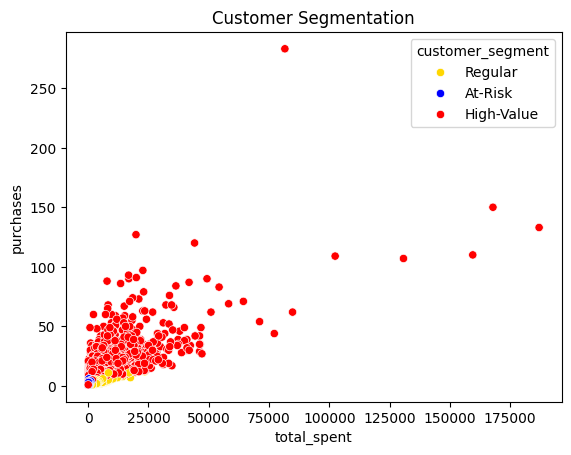

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pdf = clusters_labeled.select(
    "total_spent", "purchases", "session_count", "customer_segment"
).toPandas()

sns.scatterplot(
    data=pdf,
    x="total_spent",
    y="purchases",
    hue="customer_segment",
    palette=["gold", "blue", "red"]
)
plt.title("Customer Segmentation")
plt.show()

# Model 3 Customer Engagement Score

In [ ]:
from pyspark.sql.functions import col

df = df.withColumn(
    "engagement_score",
    0.4 * col("purchases") +
    0.3 * col("session_count") +
    0.2 * col("product_diversity") +
    0.1 * col("category_diversity")
)

In [ ]:
from pyspark.ml.feature import VectorAssembler, MinMaxScaler

assembler = VectorAssembler(
    inputCols=["engagement_score"],
    outputCol="engagement_vec"
)
df = assembler.transform(df)

scaler = MinMaxScaler(
    inputCol="engagement_vec",
    outputCol="features"
)
scaler_model = scaler.fit(df)
df = scaler_model.transform(df)

In [ ]:
kmeans = KMeans(
    featuresCol="features",
    predictionCol="cluster",
    k=3,
    seed=42
)

score_model = kmeans.fit(df)
df = score_model.transform(df)

df.select("engagement_score", "cluster").show()

+------------------+-------+
|  engagement_score|cluster|
+------------------+-------+
|               2.2|      0|
|0.9999999999999999|      0|
|               2.0|      0|
|               2.6|      0|
|2.9000000000000004|      0|
|               6.9|      2|
|              15.3|      1|
|0.9999999999999999|      0|
|               1.3|      0|
|               1.3|      0|
|               3.3|      0|
|1.6999999999999997|      0|
|2.4000000000000004|      0|
|0.9999999999999999|      0|
|0.9999999999999999|      0|
|               4.0|      0|
|3.5000000000000004|      0|
|              29.0|      1|
|3.9999999999999996|      0|
| 4.199999999999999|      2|
+------------------+-------+
only showing top 20 rows


In [ ]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

score = evaluator.evaluate(df)
print("Silhouette Score:", score)

Silhouette Score: 0.8267349353877872


In [ ]:
scaler_model.write().overwrite().save("engagement_kmeans_scaler")
score_model.write().overwrite().save("engagement_kmeans_model")

In [ ]:
import shutil
shutil.make_archive("engagement_kmeans_model", "zip", "engagement_kmeans_model")

'/content/engagement_kmeans_model.zip'

# SCIKIT LEARN

Model 1 Customer Churn Prediction

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# -----------------------------
# Feature columns
# -----------------------------
feature_cols = [
    "purchases",
    "total_spent",
    "avg_purchase_price",
    "product_diversity",
    "category_diversity",
    "session_count",
]

# -----------------------------
# If df is PySpark DataFrame, convert to pandas
# -----------------------------
pdf = df.select(feature_cols + ["churn"]).toPandas()

# -----------------------------
# X and y
# -----------------------------
X = pdf[feature_cols]
y = pdf["churn"]

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Standard scaling
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Random Forest model
# -----------------------------
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test_scaled)

# probability of churn
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# -----------------------------
# Evaluation
# -----------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# -----------------------------
# Save model and scaler
# -----------------------------
joblib.dump(model, "churn_rf_model1.pkl")
joblib.dump(scaler, "churn_rf_scaler1.pkl")
joblib.dump(feature_cols, "churn_feature_cols1.pkl")

print("Model, scaler, and feature columns saved successfully.")

Accuracy: 0.8082024574823012

Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.89     29281
           1       0.84      0.08      0.15      7586

    accuracy                           0.81     36867
   macro avg       0.82      0.54      0.52     36867
weighted avg       0.81      0.81      0.74     36867


Confusion Matrix:
 [[29162   119]
 [ 6952   634]]
Model, scaler, and feature columns saved successfully.


model 2 Customer Segmentation

In [ ]:
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# -----------------------------
# Feature columns
# -----------------------------
feature_cols1 = [
    "purchases",
    "total_spent",
    "avg_purchase_price",
    "product_diversity",
    "category_diversity",
    "session_count"
]

# -----------------------------
# If df is PySpark DataFrame, convert to pandas
# -----------------------------
pdf = df.select(feature_cols).toPandas()

# -----------------------------
# Prepare X
# -----------------------------
X = pdf[feature_cols1]

# -----------------------------
# Standard scaling
# -----------------------------
segment_scaler = StandardScaler()
X_scaled = segment_scaler.fit_transform(X)

# -----------------------------
# KMeans model
# -----------------------------
segment_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

segment_model.fit(X_scaled)

# -----------------------------
# Predict clusters
# -----------------------------
pdf["prediction"] = segment_model.predict(X_scaled)

# -----------------------------
# Map cluster to segment name
# -----------------------------
segment_map = {
    2: "High-Value",
    0: "Regular",
    1: "At-Risk"
}

pdf["customer_segment"] = pdf["prediction"].map(segment_map)

# -----------------------------
# Show result
# -----------------------------
print(pdf[feature_cols + ["prediction", "customer_segment"]].head())

# -----------------------------
# Save model
# -----------------------------
joblib.dump(segment_scaler, "segment_scaler.pkl")
joblib.dump(segment_model, "segment_model.pkl")
joblib.dump(feature_cols, "segment_feature_cols.pkl")

print("Segmentation model saved successfully.")

   purchases  total_spent  avg_purchase_price  product_diversity  \
0          2      2633.74         1316.870000                  2   
1          1      1413.16         1413.160000                  1   
2          2       980.68          490.340000                  2   
3          3      2234.27          744.756667                  2   
4          1       257.15          257.150000                  1   

   category_diversity  session_count  prediction customer_segment  
0                   1              3           1          At-Risk  
1                   1              1           1          At-Risk  
2                   5              1           1          At-Risk  
3                   1              3           1          At-Risk  
4                   2              7           1          At-Risk  
Segmentation model saved successfully.


Model 3 customer engagement score

In [ ]:
import pandas as pd
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -----------------------------
# Needed columns
# -----------------------------
feature_cols = [
    "purchases",
    "session_count",
    "product_diversity",
    "category_diversity"
]

# -----------------------------
# If df is PySpark DataFrame, convert to pandas
# -----------------------------
pdf = df.select(feature_cols).toPandas()

# -----------------------------
# Create engagement score
# -----------------------------
pdf["engagement_score"] = (
    0.4 * pdf["purchases"] +
    0.3 * pdf["session_count"] +
    0.2 * pdf["product_diversity"] +
    0.1 * pdf["category_diversity"]
)

# -----------------------------
# Scale engagement score
# -----------------------------
engagement_scaler = MinMaxScaler()
X = engagement_scaler.fit_transform(pdf[["engagement_score"]])

# -----------------------------
# KMeans model
# -----------------------------
engagement_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

engagement_model.fit(X)

# -----------------------------
# Predict cluster
# -----------------------------
pdf["cluster"] = engagement_model.predict(X)

# -----------------------------
# Silhouette score
# -----------------------------
score = silhouette_score(X, pdf["cluster"])
print("Silhouette Score:", score)

# -----------------------------
# Optional: label clusters
# -----------------------------
cluster_means = (
    pdf.groupby("cluster")["engagement_score"]
    .mean()
    .sort_values()
)

print("Cluster mean engagement scores:")
print(cluster_means)

# Example automatic labeling:
sorted_clusters = cluster_means.index.tolist()

engagement_label_map = {
    sorted_clusters[0]: "Low Engagement",
    sorted_clusters[1]: "Medium Engagement",
    sorted_clusters[2]: "High Engagement"
}

pdf["engagement_label"] = pdf["cluster"].map(engagement_label_map)

print(pdf[["engagement_score", "cluster", "engagement_label"]].head())

# -----------------------------
# Save model artifacts
# -----------------------------
joblib.dump(engagement_scaler, "engagement_scaler.pkl")
joblib.dump(engagement_model, "engagement_model.pkl")
joblib.dump(engagement_label_map, "engagement_label_map.pkl")

print("Engagement model saved successfully.")

Silhouette Score: 0.6809972477810997
Cluster mean engagement scores:
cluster
0     1.967019
2     6.067211
1    16.518113
Name: engagement_score, dtype: float64
   engagement_score  cluster engagement_label
0               2.2        0   Low Engagement
1               1.0        0   Low Engagement
2               2.0        0   Low Engagement
3               2.6        0   Low Engagement
4               2.9        0   Low Engagement
Engagement model saved successfully.
